# Empirical Analysis of European Union GDP Dynamics: A Macroeconomic Framework

## 1. Theoretical Note on Gross Domestic Product

Gross Domestic Product (GDP) represents the preeminent macroeconomic aggregate utilized to quantify the total economic output of a defined sovereign or supranational entity over a specified temporal horizon. Formally, it measures the aggregate market value of all final goods and services produced within a strictly defined geographical jurisdiction.

From an expenditure perspective, GDP is conceptualized as the sum of all final demands in the economy. This relationship is codified in the fundamental national income accounting identity:

$Y = C + I + G + NX$

Where:
* **$Y$**: Gross Domestic Product.
* **$C$**: Final Consumption Expenditure (household expenditures).
* **$I$**: Gross Capital Formation (corporate investment in capital goods, inventory changes).
* **$G$**: Government Final Consumption Expenditure.
* **$NX$**: Net Exports, mathematically defined as total exports minus total imports ($X - M$).

### Real vs. Nominal GDP
A critical analytical distinction must be drawn between Nominal and Real GDP. 
* **Nominal GDP** evaluates economic output utilizing current market prices, making it susceptible to variations in the general price level (inflation or deflation). 
* **Real GDP** strips out this inflationary distortion by valuing output at the constant prices of a designated base year (often computed via chain-linked volumes). Consequently, Real GDP isolates pure volumetric growth in economic output, serving as a superior metric for cross-temporal welfare and productivity comparisons.

### Macroeconomic Significance
As a diagnostic instrument, GDP provides the fundamental baseline for monetary and fiscal policy formulation. The first derivative of Real GDP with respect to time yields the economic growth rate, the primary proxy for the phase of the business cycle. Furthermore, it serves as the essential denominator for key sovereign risk metrics, most notably the debt-to-GDP ratio, which is paramount in fixed-income sovereign pricing and risk modeling.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

%load_ext sql
%sql duckdb:///:memory:

Connecting to 'duckdb:///:memory:'

In [5]:
%%sql processed_components <<
INSTALL httpfs;
LOAD httpfs;

WITH raw_api AS (
    -- Scarichiamo le componenti: P31_S14_S15 (C), P3_S13 (G), P5G (I), P6 (X), P7 (M)
    SELECT 
        CAST(TIME_PERIOD AS INTEGER) AS year,
        CASE 
            WHEN geo = 'DE' THEN 'Germania'
            WHEN geo = 'FR' THEN 'Francia'
            WHEN geo = 'IT' THEN 'Italia'
            WHEN geo = 'ES' THEN 'Spagna'
        END AS country,
        na_item,
        OBS_VALUE AS value
    FROM read_csv_auto('https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/nama_10_gdp/A.CLV15_MEUR.P31_S14_S15+P3_S13+P5G+P6+P7.DE+FR+IT+ES?format=SDMX-CSV')
    WHERE OBS_VALUE IS NOT NULL
),
pivoted_items AS (
    -- Ruotiamo le componenti in colonne per calcolare agevolmente il Net Export
    PIVOT raw_api
    ON na_item
    USING FIRST(value)
    GROUP BY year, country
)
SELECT 
    year,
    country,
    P31_S14_S15 / 1000 AS Consumption_C,
    P3_S13 / 1000 AS Government_G,
    P5G / 1000 AS Investment_I,
    (P6 - P7) / 1000 AS NetExports_NX
FROM pivoted_items
ORDER BY year DESC, country;

Running query in 'duckdb:///:memory:'

## 2. Empirical Visualization of Trajectories

Having isolated the Real GDP series (Chain-linked volumes, base 2010), we proceed to visually inspect the secular trends and cyclical fluctuations of the primary Eurozone economies. This visualization allows us to empirically identify historical structural breaks—such as the 2008 Global Financial Crisis and the 2020 exogenous macroeconomic shock induced by the COVID-19 pandemic—and assess the differential recovery trajectories across the selected sovereign states.

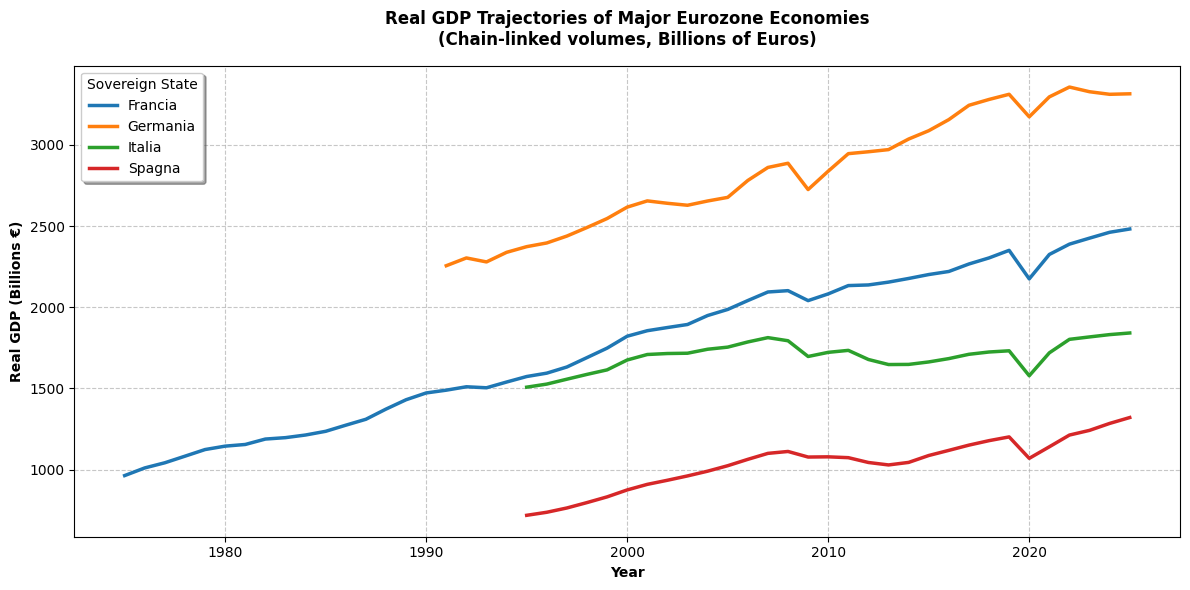

In [7]:
# Data Visualization

# 1. Convertiamo il risultato SQL in un vero DataFrame Pandas
# Usiamo processed_components che è la variabile definita nella cella SQL
df = processed_components.DataFrame()

# 2. Calcoliamo il PIL Reale aggregando le componenti (Y = C + G + I + NX)
df['Real_GDP'] = df['Consumption_C'] + df['Government_G'] + df['Investment_I'] + df['NetExports_NX']

# 3. Creiamo una Pivot Table: 'year' come asse temporale, 'country' come serie storiche
df_plot = df.pivot(index='year', columns='country', values='Real_GDP')

fig, ax = plt.subplots(figsize=(12, 6))

# 4. Tracciamo le traiettorie temporali
# Nota: omettiamo la divisione per 1000 perché è già stata eseguita in SQL
for country in df_plot.columns:
    ax.plot(df_plot.index, df_plot[country], linewidth=2.5, label=country)

# Formatting the axes and title for academic presentation
ax.set_title('Real GDP Trajectories of Major Eurozone Economies\n(Chain-linked volumes, Billions of Euros)', fontweight='bold', pad=15)
ax.set_xlabel('Year', fontweight='bold')
ax.set_ylabel('Real GDP (Billions €)', fontweight='bold')

# Enhance grid readability
ax.grid(True, linestyle='--', alpha=0.7)

# Add legend
ax.legend(title='Sovereign State', loc='upper left', frameon=True, shadow=True)

# Tight layout for export readiness
plt.tight_layout()
plt.show()

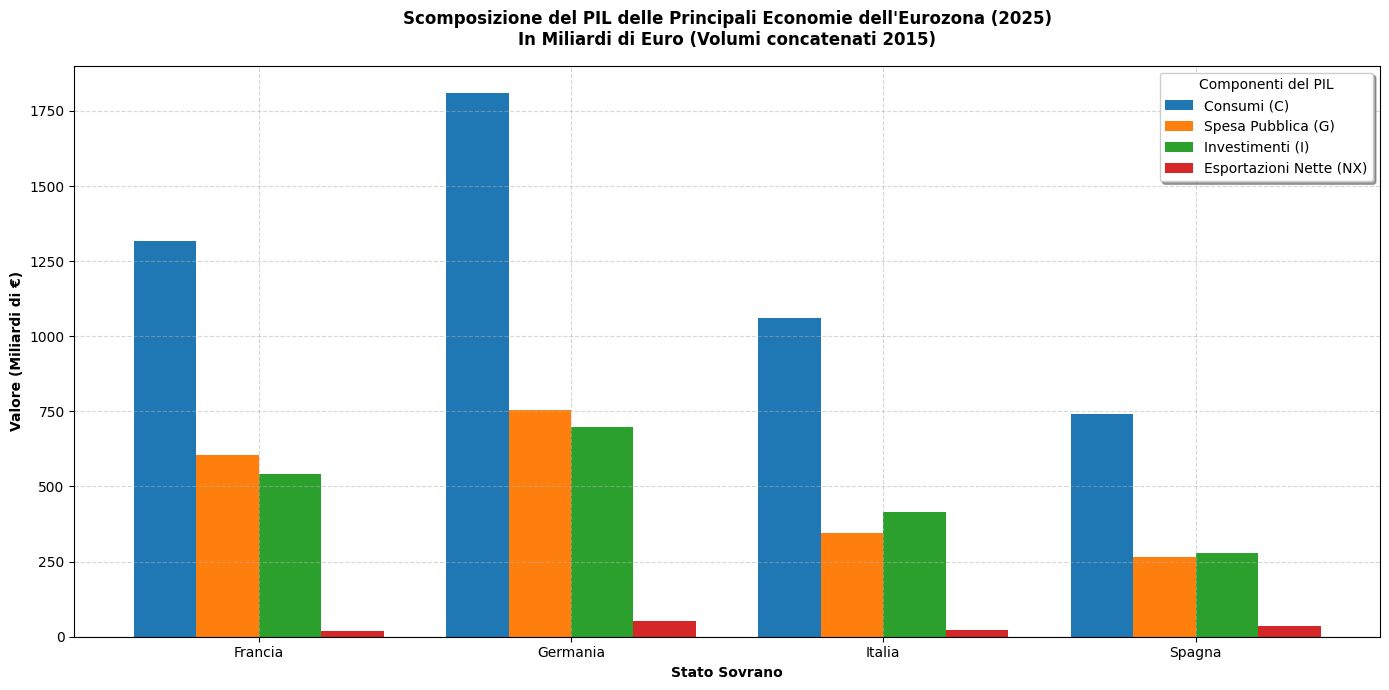

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Convertiamo il ResultSet in DataFrame Pandas
df_comp = processed_components.DataFrame()

# 2. Identifichiamo l'anno più recente disponibile
current_year = df_comp['year'].max()
df_current = df_comp[df_comp['year'] == current_year].set_index('country')

# 3. Prepariamo i dati per l'istogramma a barre raggruppate
countries = df_current.index.tolist()
components = ['Consumption_C', 'Government_G', 'Investment_I', 'NetExports_NX']
labels = ['Consumi (C)', 'Spesa Pubblica (G)', 'Investimenti (I)', 'Esportazioni Nette (NX)']

x = np.arange(len(countries))  # Posizionamento dei gruppi di paesi
width = 0.2  # Larghezza delle singole barre

fig, ax = plt.subplots(figsize=(14, 7))

# Tracciamo una barra per ogni componente macroeconomica
for i, comp in enumerate(components):
    ax.bar(x + (i * width) - (width * 1.5), df_current[comp], width, label=labels[i])

# Formattazione estetica e accademica
ax.set_title(f'Scomposizione del PIL delle Principali Economie dell\'Eurozona ({current_year})\nIn Miliardi di Euro (Volumi concatenati 2015)', fontweight='bold', pad=15)
ax.set_xlabel('Stato Sovrano', fontweight='bold')
ax.set_ylabel('Valore (Miliardi di €)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(countries)

# Linea di riferimento sullo zero (utile per comprendere il deficit/surplus commerciale di NX)
ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Componenti del PIL', frameon=True, shadow=True)

plt.tight_layout()
plt.show()